## ETS-ANN Hybrid Model based on Panigrahi Algorithm Steps

## Import Libraries

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import MinMaxScaler
from pycaret.time_series import TSForecastingExperiment, setup, create_model, compare_models, predict_model, get_config
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, r2_score
import yfinance as yf
from sklearn.model_selection import train_test_split

## Step 1: Given Time Series y

In [47]:
# Download Bitcoin data
df_ETH = yf.download(
    tickers=["ETH-USD"],
    start="2020-01-01",
    end="2025-01-01" # yf downloads up to the day before
)

# Basic Cleaning and Selection
# Rename for clarity
df_ETH.columns = ['Open', 'High', 'Low', 'Close', 'Volume'] 
print(f"Original shape: {df_ETH.shape}")
# Forward fill for potential missing values
df_ETH.ffill(inplace=True)

# Select Target and Set Index
df_ETH.reset_index(inplace=True)
df_ETH['Date'] = pd.to_datetime(df_ETH['Date'], format='%Y-%m-%d')
df_ETH = df_ETH[['Date', 'Close']]
df_ETH.set_index('Date', inplace=True)

# Ensure Daily Frequency
df_ETH = df_ETH.asfreq('D')
# Fill again if necessary
df_ETH.ffill(inplace=True)  
print(f"Shape after preproc: {df_ETH.shape}")
print(f"Frequency of the index: {df_ETH.index.freq}")
print("\nData Head:")
print(df_ETH.head())
# The full time series y_t
y_full = df_ETH['Close']

[*********************100%***********************]  1 of 1 completed

Original shape: (1827, 5)
Shape after preproc: (1827, 1)
Frequency of the index: <Day>

Data Head:
                 Close
Date                  
2020-01-01  129.630661
2020-01-02  130.820038
2020-01-03  127.411263
2020-01-04  134.168518
2020-01-05  135.072098


## Step 2: Defining In-Sample (Train 60% +Val 20%) and Out-of-Sample (Test 20%) Splits

In [48]:
n_total = len(y_full)
n_train = int(0.6 * n_total)
n_val = int(0.2 * n_total)
n_test = n_total - n_train - n_val
n_insample = n_train + n_val # l_i in Algorithm 1

y_train_data = y_full[:n_train]
y_val_data = y_full[n_train:n_insample]
y_insample_data = y_full[:n_insample] # Data for used in the steps 4-9 (l_i)
y_test_data = y_full[n_insample:]     # Data for final evaluation (l_o)

print(f"Total samples: {n_total}")
print(f"In-Sample (l_i): {n_insample} (Train: {n_train}, Val: {n_val})")
print(f"Out-of-Sample (l_o): {n_test}")
print(f"In-Sample Start: {y_insample_data.index.min()}, End: {y_insample_data.index.max()}")
print(f"Out-of-Sample Start: {y_test_data.index.min()}, End: {y_test_data.index.max()}")

# Define forecast horizon for PyCaret setup (length of test set)
fh_test = n_test

Total samples: 1827
In-Sample (l_i): 1461 (Train: 1096, Val: 365)
Out-of-Sample (l_o): 366
In-Sample Start: 2020-01-01 00:00:00, End: 2023-12-31 00:00:00
Out-of-Sample Start: 2024-01-01 00:00:00, End: 2024-12-31 00:00:00


## Step 3 & 4: Normalize In-Sample & Determine Best ETS
Here the focus is on picking the best forecasting model (ETS). Any special adjustments to the initial data will be skipped for now, letting PyCaret handle any necessary scaling behind the scenes. When the PyCaret is set up with the entire dataset and it is told how many future periods it is needed to predict (fh=n_test), it  creates its own internal training set. This internal training data is essentially called 'y_insample_data' – the historical data which will be used to train and find the best ETS model.

In [ ]:
# Setup PyCaret using the FULL data, defining fh=n_test creates the correct internal train/test split
# The internal training data corresponds conceptually to the 'y_insample_data' for fitting purposes
exp_eth = TSForecastingExperiment()
setup(data=df_ETH, 
      target='Close',
      fh=fh_test,
      session_id=123,
      numeric_imputation_target="ffill"
     )

# Retrieve PyCaret's internal training data for clarity (as this is what models fit on)
y_train_pycaret = get_config('y_train')
print(f"\nPyCaret Internal Training Data length: {len(y_train_pycaret)}")
print(f"Matches expected In-Sample length? {len(y_train_pycaret) == n_insample}") # Should be True or very close

print("\n--- Comparing ETS Models (using PyCaret's internal validation) ---")
# compare_models evaluates on PyCaret's internal validation set (hold-out defined by fh)
best_ets_model_obj = compare_models(include=['ets', 'exp_smooth'],
                                    sort='RMSE',
                                    n_select=1)

print(f"\n--- Best ETS Model Selected by PyCaret: ---")
print(best_ets_model_obj)

,Description,Value
0,session_id,123
1,Target,Close
2,Approach,Univariate
3,Exogenous Variables,Not Present
4,Original data shape,"(1827, 1)"
5,Transformed data shape,"(1827, 1)"
6,Transformed train set shape,"(1461, 1)"
7,Transformed test set shape,"(366, 1)"
8,Rows with missing values,0.0%
9,Fold Generator,ExpandingWindowSplitter



PyCaret Internal Training Data length: 1461
Matches expected In-Sample length? True

--- Comparing ETS Models (using PyCaret's internal validation) ---


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
ets,ETS,29.9935,22.8849,1448.3283,1603.5479,0.7536,0.6174,-4.3741,1.3600
exp_smooth,Exponential Smoothing,30.6143,23.2660,1567.1261,1737.7420,0.8358,0.6322,-5.5474,0.4167



--- Best ETS Model Selected by PyCaret: ---
AutoETS(seasonal='mul', sp=6, trend='add')


## Step 5 & 6: Obtain ETS In-Sample Predictions getting fitted values on original scale directly. No de-normalization needed.

In [50]:
print("\n--- Obtaining In-Sample ETS Fitted Values ---")
# Use the fitted model object from PyCaret
try:
    # Access fitted values from the underlying statsmodels/sktime object
    # Ensure these correspond to the training data PyCaret used (y_train_pycaret)
    ets_fitted_values_train = best_ets_model_obj._fitted_forecaster.fittedvalues
    # Align index explicitly with PyCaret's training index
    ets_fitted_values_train = ets_fitted_values_train.reindex(y_train_pycaret.index)

except AttributeError:
    print("Warning: Could not directly access fittedvalues. Predicting on training data as fallback.")
    # Predict on the training data PyCaret used
    ets_fitted_values_train = predict_model(best_ets_model_obj, X=get_config('X_train'))['y_pred']
    # Ensuring the index matches PyCaret's training index
    ets_fitted_values_train = ets_fitted_values_train.reindex(y_train_pycaret.index)

# Checking alignment
if not y_train_pycaret.index.equals(ets_fitted_values_train.index):
     print("WARNING: Index mismatch between y_train_pycaret and ETS fitted values after reindex.")
else:
     print("Indices between y_train_pycaret and ETS fitted values aligned.")

# Drop any NaNs potentially introduced at the start by the ETS model fitting
ets_fitted_values_train.dropna(inplace=True)
# Align original training data to match the valid fitted values index
y_train_pycaret_aligned = y_train_pycaret.reindex(ets_fitted_values_train.index)

print(f"Number of valid ETS fitted values: {len(ets_fitted_values_train)}")
print("ETS Fitted Values Head:")
print(ets_fitted_values_train.head())

# These fitted values represent Č_t^1 for the in-sample period (t=1 to l_i)


--- Obtaining In-Sample ETS Fitted Values ---
Indices between y_train_pycaret and ETS fitted values aligned.
Number of valid ETS fitted values: 1461
ETS Fitted Values Head:
Date
2020-01-01    134.286369
2020-01-02    130.522338
2020-01-03    132.249508
2020-01-04    129.572900
2020-01-05    135.375959
Freq: D, dtype: float64


## Step 7: Obtain Residual Series (In-Sample)
## e_t = y_t - Č_t^1 (for t = 1 to l_i)


--- Calculating In-Sample Residuals ---
Number of valid In-Sample Residuals: 1461
Residuals Head:
Date
2020-01-01   -4.655708
2020-01-02    0.297699
2020-01-03   -4.838245
2020-01-04    4.595618
2020-01-05   -0.303861
Freq: D, dtype: float64


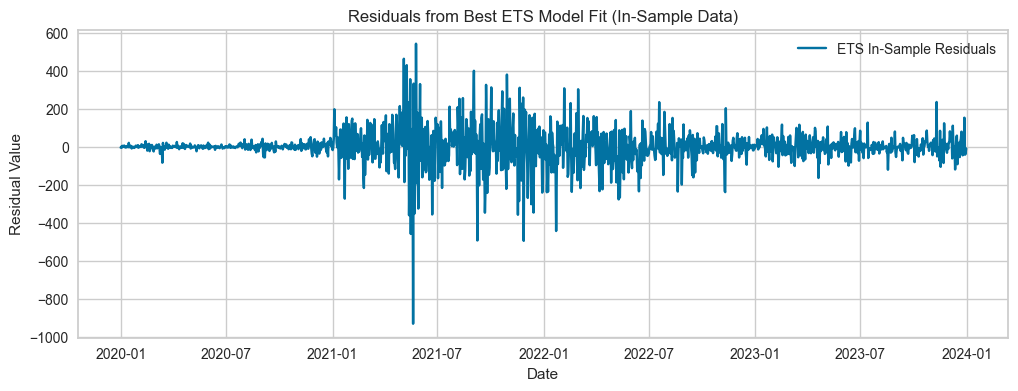

In [51]:
print("\n--- Calculating In-Sample Residuals ---")
# Using the aligned PyCaret training data and the valid fitted values
residuals_insample = y_train_pycaret_aligned - ets_fitted_values_train
residuals_insample.dropna(inplace=True) 

print(f"Number of valid In-Sample Residuals: {len(residuals_insample)}")
print("Residuals Head:")
print(residuals_insample.head())

plt.figure(figsize=(12, 4))
plt.plot(residuals_insample.index.to_timestamp(), residuals_insample, label='ETS In-Sample Residuals')
plt.title('Residuals from Best ETS Model Fit (In-Sample Data)')
plt.xlabel('Date')
plt.ylabel('Residual Value')
plt.legend()
plt.grid(True)
plt.show()

## Step 8 & 9: Perform Lag Selection (Using Fixed Lags) & Normalize Residuals
## Normalize the valid in-sample residual series e_t using its own min/max

In [52]:
# Step 8: Lag Selection (Using predefined lags)
lags_to_use = [1, 7, 30]
print(f"\nUsing fixed lags for ANN: {lags_to_use}")

# Step 9: Normalize the calculated in-sample residuals
print("\n--- Normalizing In-Sample Residuals ---")
scaler_residuals = MinMaxScaler(feature_range=(-1, 1)) # Scaler for residuals
# Fitting scaler only on the valid in-sample residuals
normalized_residuals_insample = scaler_residuals.fit_transform(residuals_insample.values.reshape(-1, 1))

# Converting back to Series with correct index
normalized_residuals_insample_series = pd.Series(normalized_residuals_insample.flatten(), index=residuals_insample.index)

print("Normalized Residuals Head:")
print(normalized_residuals_insample_series.head())


Using fixed lags for ANN: [1, 7, 30]

--- Normalizing In-Sample Residuals ---
Normalized Residuals Head:
Date
2020-01-01    0.258124
2020-01-02    0.264857
2020-01-03    0.257876
2020-01-04    0.270699
2020-01-05    0.264039
Freq: D, dtype: float64


## Step 10a: Prepare Lagged Residual Data for ANN

In [53]:
# Create lagged features from the normalized in-sample residuals
def create_lagged_features_ann(series, lags):
    lagged_data = pd.DataFrame(index=series.index)
    lagged_data['target'] = series # Target is the normalized residual
    for lag in lags:
        lagged_data[f'lag_{lag}'] = series.shift(lag)
    lagged_data.dropna(inplace=True) # Removing NaNs from shifting
    return lagged_data

lagged_normalized_residuals = create_lagged_features_ann(normalized_residuals_insample_series, lags_to_use)

print("\n--- Lagged Normalized Residual Features Created ---")
print(f"Shape of lagged residual data for ANN: {lagged_normalized_residuals.shape}")
print("Lagged Data Head:")
print(lagged_normalized_residuals.head())

# Separate features (X) and target (y) for ANN training/tuning
X_ann_resid = lagged_normalized_residuals.drop('target', axis=1)
y_ann_resid = lagged_normalized_residuals['target']


--- Lagged Normalized Residual Features Created ---
Shape of lagged residual data for ANN: (1431, 4)
Lagged Data Head:
              target     lag_1     lag_7    lag_30
Date                                              
2020-01-31  0.275092  0.261061  0.255645  0.258124
2020-02-01  0.257281  0.275092  0.262023  0.264857
2020-02-02  0.267164  0.257281  0.260868  0.257876
2020-02-03  0.267991  0.267164  0.271802  0.270699
2020-02-04  0.264651  0.267991  0.265120  0.264039


## Step 10b: ANN Tuning (Using Validation Split within In-Sample Residuals)

In [54]:
# --- Tuning Loop ---
neuron_options = [25, 50, 100]
epochs_options = [30, 50]
batch_size_options = [32, 64]

# Split the valid residual feature data for ANN tuning (e.g., 80% train, 20% validation within this set)
# This conceptually uses the 60% original for train, 20% original for validation
X_ann_train_tune, X_ann_val_tune, y_ann_train_tune, y_ann_val_tune = train_test_split(
    X_ann_resid, y_ann_resid, test_size=0.25, shuffle=False # 0.25 * 0.80 = 0.20 of total
)

print("\n--- Data Split for ANN Tuning (from Residuals) ---")
print(f"ANN Tuning Train shape: {X_ann_train_tune.shape}")
print(f"ANN Tuning Validation shape: {X_ann_val_tune.shape}")

# --- Starting ANN Hyperparameter Tuning ---
best_val_mse = float('inf')
best_params_ann = None

print("\n--- Starting ANN Hyperparameter Tuning ---")
for neurons in neuron_options:
    for epochs in epochs_options:
        for batch_size in batch_size_options:
            print(f"Trying: Neurons={neurons}, Epochs={epochs}, Batch Size={batch_size}")

            # Build ANN model for this trial
            ann_model_tune = Sequential([
                Dense(neurons, activation='relu', input_shape=(X_ann_train_tune.shape[1],)),
                Dense(max(10, neurons//2), activation='relu'), # Example second layer
                Dense(1) # Linear output for regression
            ])
            ann_model_tune.compile(optimizer=Adam(learning_rate=0.001), loss='mse') # Use a consistent learning rate

            # Train model on tuning training set, validate on tuning validation set
            history = ann_model_tune.fit(X_ann_train_tune.values, y_ann_train_tune.values,
                                         epochs=epochs,
                                         batch_size=batch_size,
                                         validation_data=(X_ann_val_tune.values, y_ann_val_tune.values),
                                         verbose=0) # Set verbose=0 to avoid excessive output during tuning

            # Evaluate on tuning validation set using the recorded history
            # Ensure history.history['val_loss'] is not empty
            if 'val_loss' in history.history and len(history.history['val_loss']) > 0:
                 val_mse = history.history['val_loss'][-1] # Get final validation MSE from the last epoch
                 print(f"  Validation MSE: {val_mse:.6f}")

                 # Update best parameters if current model is better
                 if val_mse < best_val_mse:
                     best_val_mse = val_mse
                     best_params_ann = {'neurons': neurons, 'epochs': epochs, 'batch_size': batch_size}
            else:
                 print("Warning: No validation loss recorded for this trial.")
                 val_mse = float('inf') # Assign infinite MSE if training failed or val_loss was not recorded


print("\n--- ANN Tuning Complete ---")
if best_params_ann is None:
     raise ValueError("ANN Tuning failed. No valid parameters found. Check training logs.")

print(f"Best Hyperparameters found (based on Validation MSE): {best_params_ann}")
print(f"Best Validation MSE: {best_val_mse:.6f}")


--- Data Split for ANN Tuning (from Residuals) ---
ANN Tuning Train shape: (1073, 3)
ANN Tuning Validation shape: (358, 3)

--- Starting ANN Hyperparameter Tuning ---
Trying: Neurons=25, Epochs=30, Batch Size=32


  Validation MSE: 0.003730
Trying: Neurons=25, Epochs=30, Batch Size=64


  Validation MSE: 0.003687
Trying: Neurons=25, Epochs=50, Batch Size=32


  Validation MSE: 0.003689
Trying: Neurons=25, Epochs=50, Batch Size=64


  Validation MSE: 0.003657
Trying: Neurons=50, Epochs=30, Batch Size=32


...

  Validation MSE: 0.003646
Trying: Neurons=50, Epochs=50, Batch Size=64


  Validation MSE: 0.003660
Trying: Neurons=100, Epochs=30, Batch Size=32


  Validation MSE: 0.003598
Trying: Neurons=100, Epochs=30, Batch Size=64


  Validation MSE: 0.003593
Trying: Neurons=100, Epochs=50, Batch Size=32


  Validation MSE: 0.005207
Trying: Neurons=100, Epochs=50, Batch Size=64
  Validation MSE: 0.003966

--- ANN Tuning Complete ---
Best Hyperparameters found (based on Validation MSE): {'neurons': 100, 'epochs': 30, 'batch_size': 64}
Best Validation MSE: 0.003593


## Step 10c: Train Final ANN on All In-Sample Residual Data

In [55]:
print("\n--- Training Final ANN on All In-Sample Residual Data ---")

# Building the final model with best hyperparameters
final_ann_model = Sequential([
    Dense(best_params_ann['neurons'], activation='relu', input_shape=(X_ann_resid.shape[1],)),
    Dense(max(10, best_params_ann['neurons']//2), activation='relu'),
    Dense(1) # Linear output
])
final_ann_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Train on the entire lagged residual dataset (X_ann_resid, y_ann_resid)
final_ann_model.fit(X_ann_resid.values, y_ann_resid.values,
                    epochs=best_params_ann['epochs'],
                    batch_size=best_params_ann['batch_size'],
                    verbose=1)

print("\n--- Final ANN Model Training Complete ---")
final_ann_model.summary()


--- Training Final ANN on All In-Sample Residual Data ---
Epoch 1/30
23/23 [==============================] - 0s 1ms/step - loss: 0.0466
Epoch 2/30
23/23 [==============================] - 0s 2ms/step - loss: 0.0183
Epoch 3/30
23/23 [==============================] - 0s 1ms/step - loss: 0.0170
Epoch 4/30
23/23 [==============================] - 0s 926us/step - loss: 0.0165
Epoch 5/30
23/23 [==============================] - 0s 1ms/step - loss: 0.0161
Epoch 6/30
23/23 [==============================] - 0s 13ms/step - loss: 0.0158
Epoch 7/30
23/23 [==============================] - 0s 2ms/step - loss: 0.0154
Epoch 8/30
23/23 [==============================] - 0s 1ms/step - loss: 0.0155
Epoch 9/30
23/23 [==============================] - 0s 624us/step - loss: 0.0154
Epoch 10/30
23/23 [==============================] - 0s 946us/step - loss: 0.0152
Epoch 11/30
23/23 [==============================] - 0s 1ms/step - loss: 0.0152
Epoch 12/30
23/23 [==============================] - 0s 750us/s

## Step 11 (Out-of-Sample): Obtain ANN Predictions & De-normalize
## Generate multi-step iterative forecast for residuals (Č_t^2)

In [56]:
print("\n--- Generating ANN Residual Multi-Step Forecast (Iterative) ---")

# 1. Get last known normalized residuals from the end of the in-sample period
last_known_normalized_residuals = normalized_residuals_insample_series.tail(max(lags_to_use)).values

# 2. Initialize forecast list and history
ann_preds_holdout_normalized_list = []
current_history_normalized = list(last_known_normalized_residuals)

# 3. Iterative forecast loop for the length of the test set (n_test or fh_test)
print(f"Forecasting {fh_test} steps ahead...")
for i in range(fh_test):
    input_vector = np.array([current_history_normalized[-lag] for lag in lags_to_use]).reshape(1, -1)
    next_pred_normalized = final_ann_model.predict(input_vector, verbose=0)[0, 0]
    ann_preds_holdout_normalized_list.append(next_pred_normalized)
    current_history_normalized.append(next_pred_normalized)
    current_history_normalized.pop(0)

# 4. Convert predictions to Series with the test set index
ann_pred_holdout_normalized = pd.Series(ann_preds_holdout_normalized_list, index=y_test_data.index)

# 5. De-normalize using the scaler fitted on in-sample residuals (scaler_residuals)
ann_pred_holdout_denormalized = scaler_residuals.inverse_transform(ann_pred_holdout_normalized.values.reshape(-1, 1)).flatten()
ann_pred_holdout_denormalized = pd.Series(ann_pred_holdout_denormalized, index=y_test_data.index) # Č_t^2 for out-of-sample

print("\nDe-normalized ANN Residual Predictions (Hold-out) Head:")
print(ann_pred_holdout_denormalized.head())


--- Generating ANN Residual Multi-Step Forecast (Iterative) ---
Forecasting 366 steps ahead...

De-normalized ANN Residual Predictions (Hold-out) Head:
Date
2024-01-01    6.996146
2024-01-02    4.824224
2024-01-03    7.113162
2024-01-04   -4.398160
2024-01-05    7.871537
Freq: D, dtype: float32


## Step 12 (Out-of-Sample): Obtain Final Predictions
## Combine ETS predictions (Č_t^1) with ANN predictions (Č_t^2) for out-of-sample period

In [57]:
print("\n--- Generating ETS Multi-Step Forecast for Hold-Out Period ---")
# Generate ETS forecast Č_t^1 for the out-of-sample period
ets_pred_holdout = predict_model(best_ets_model_obj) # Predicts fh_test steps

ets_pred_holdout.index = ets_pred_holdout.index.to_timestamp()
print(f"ETS Prediction Index Type: {type(ets_pred_holdout.index)}") # Verify it's DatetimeIndex

print("\n--- Combining ETS and ANN Forecasts ---")
# Ensure indices match (PyCaret's predict uses future index, matches y_test_data)
# Also checking ANN prediction index type for sanity check
print(f"ANN Prediction Index Type: {type(ann_pred_holdout_denormalized.index)}")

if not ets_pred_holdout.index.equals(ann_pred_holdout_denormalized.index):
     print("ETS Index Head:", ets_pred_holdout.index[:5])
     print("ANN Index Head:", ann_pred_holdout_denormalized.index[:5])
     raise ValueError("Index mismatch between ETS and ANN hold-out predictions even after conversion!")

# Final Forecast = ETS Forecast + De-normalized ANN Residual Forecast
final_hybrid_pred_revised = ets_pred_holdout['y_pred'] + ann_pred_holdout_denormalized

print("\nFinal Hybrid Predictions (Hold-out) Head:")
print(final_hybrid_pred_revised.head())


--- Generating ETS Multi-Step Forecast for Hold-Out Period ---


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,ETS,4.3401,3.3185,570.4659,706.0682,0.1716,0.1933,-0.9144


ETS Prediction Index Type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>

--- Combining ETS and ANN Forecasts ---
ANN Prediction Index Type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>

Final Hybrid Predictions (Hold-out) Head:
2024-01-01    2312.993546
2024-01-02    2308.056824
2024-01-03    2306.698262
2024-01-04    2303.645440
2024-01-05    2307.505637
Freq: D, dtype: float64


## Evaluate Final Hybrid Model Performance

In [58]:
# Define evaluation metrics function 
def ts_metrics(y, y_hat, model_name="Model"):
    mae = mean_absolute_error(y, y_hat)
    mape = mean_absolute_percentage_error(y, y_hat)
    rmse = np.sqrt(mean_squared_error(y, y_hat))
    try:
        r2 = r2_score(y, y_hat)
    except ValueError: r2 = np.nan
    print(f"\n--- {model_name} Evaluation Metrics (Hold-out Set) ---")
    print(f"RMSE: {rmse:.4f}, MAE: {mae:.4f}, MAPE: {mape:.4%}, R²: {r2:.4f}")
    return {'MAE': mae, 'MAPE': mape, 'RMSE': rmse, 'R2': r2}

# Evaluate the Hybrid model using the original test data split
hybrid_metrics_revised = ts_metrics(y_test_data, final_hybrid_pred_revised, model_name="ETS-ANN Hybrid Model")



--- ETS-ANN Hybrid Model Evaluation Metrics (Hold-out Set) ---
RMSE: 703.8046, MAE: 569.0658, MAPE: 17.1281%, R²: -0.9021


## Visualize Results

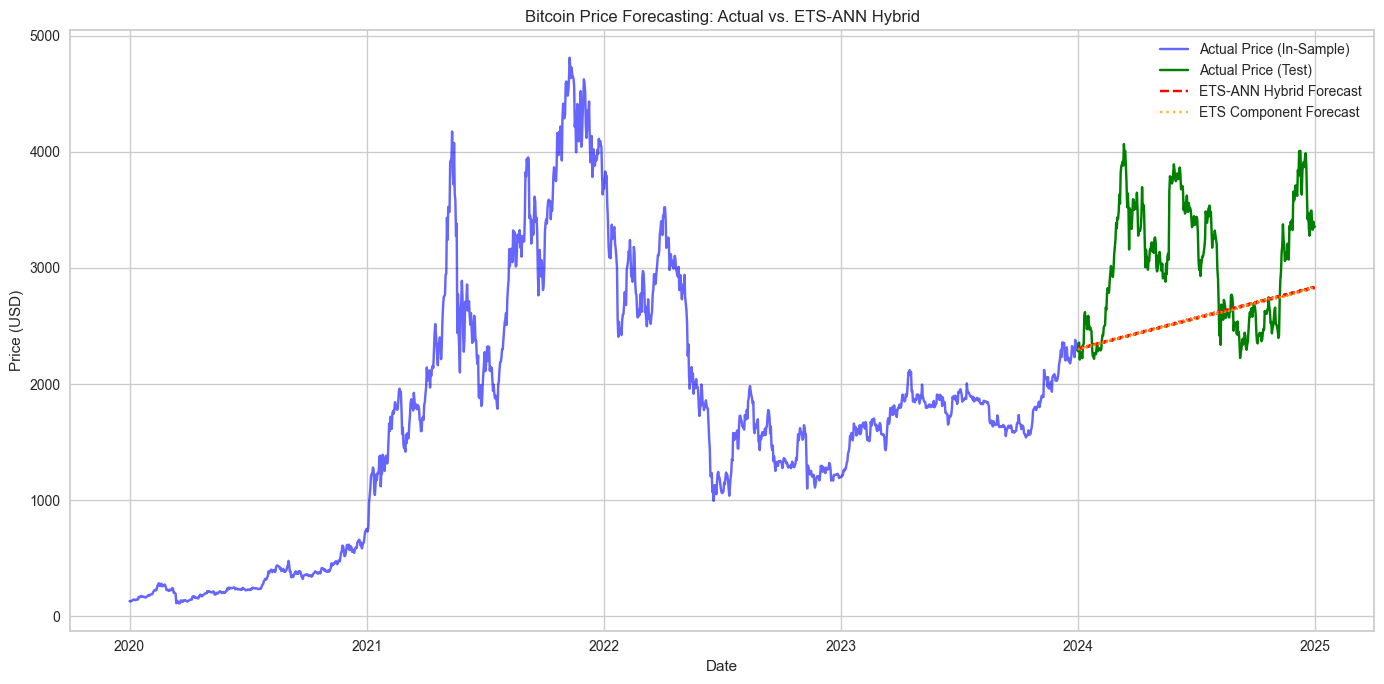

In [59]:
plt.figure(figsize=(14, 7))
plt.plot(y_insample_data.index, y_insample_data, label='Actual Price (In-Sample)', color='blue', alpha=0.6)
plt.plot(y_test_data.index, y_test_data, label='Actual Price (Test)', color='green')
plt.plot(final_hybrid_pred_revised.index, final_hybrid_pred_revised, label='ETS-ANN Hybrid Forecast', color='red', linestyle='--')
plt.plot(ets_pred_holdout.index, ets_pred_holdout['y_pred'], label='ETS Component Forecast', color='orange', linestyle=':', alpha=0.8)
plt.title('Bitcoin Price Forecasting: Actual vs. ETS-ANN Hybrid')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()